---
title: Extreme Modelling Results
date: 05/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

A notebook showcase modelling results for the `gbex` model, including interpretations. This notebook is fully in Python and calls up interemdiate plotting datasets produced in `extreme_modelling_compute_interpretations.ipynb`, that automatically get saved to `/outputs/model_fitting/gbex/plotting_data/`. You must first run through that notebook to produce the intermediate datasets before running through this one.

As in the mean modelling notebook, we will consider variable importance metrics via permutation importance, 1D and 2D PDPs to explore how model predictions vary with individual variables, and conclude with a SHAP analysis.

We do not fit any models in this notebook or evaluate prediction error on the test set as that involves `R` code and was performed in the `extreme_modelling_compute_interpretations.ipynb` notebook. Instead, we showcase the interpretations.

In [1]:
# load python packages
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import sys
sys.path.append('../scripts')
from plotting_utils import *

from abbreviations_units import ABBV_DICT, UNITS_DICT

load_path = Path('../outputs/model_fitting/gbex/plotting_data')

## Cumulative Snowfall

Let's first run through the cumulative snowfall results.

In [2]:
# load snowfall datasets

X_full_snow = pd.read_csv(load_path / 'train_test_data/gbex_snow_fullX.csv')
z_full_snow = pd.read_csv(load_path / 'train_test_data/gbex_snow_fullZ.csv')
X_train_snow = pd.read_csv(load_path / 'train_test_data/gbex_snow_trainX.csv')
z_train_snow = pd.read_csv(load_path / 'train_test_data/gbex_snow_trainZ.csv')
X_test_snow = pd.read_csv(load_path / 'train_test_data/gbex_snow_testX.csv')
z_test_snow = pd.read_csv(load_path / 'train_test_data/gbex_snow_testZ.csv')

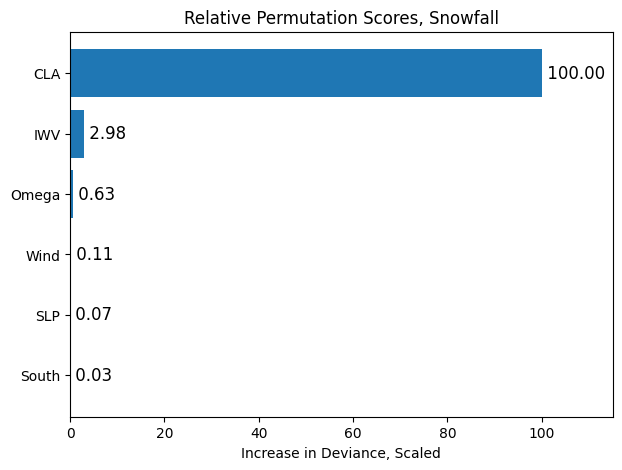

In [3]:
snow_VI_dat = pd.read_csv(load_path / 'variable_importance/snow_gbex_VI.csv', index_col=0)

snow_VI_dat = snow_VI_dat.round(4)
snow_VI_dat = snow_VI_dat.sort_values(by='avg_perm_diff', ascending=False)
tick_labels = [ABBV_DICT[varname] for varname in snow_VI_dat.index]

fig, ax = plt.subplots(figsize=(7,5))
plot_variable_importance(importances=snow_VI_dat, ax=ax, value_col='avg_perm_diff', 
                        title='Relative Permutation Scores, Snowfall', xlabel='Increase in Deviance, Scaled', normalize=True, tick_labels=tick_labels);

#fig.savefig('plots/importance_snow.png', dpi=300)

It seems like CLA once again is by far the most important predictor of the $99.5$ percentile snowfall events, similarly followed by IWV and Omega as in the mean model case. However, the relative importance of CLA is much higher than these other two.

Now, let's plot 1D partial dependence plots to explore how the average quantile predictions change as a function of varying individual variables. We'll first define a dictionary mapping variable names to abbreviations and abbreviations to units, for easier plotting.

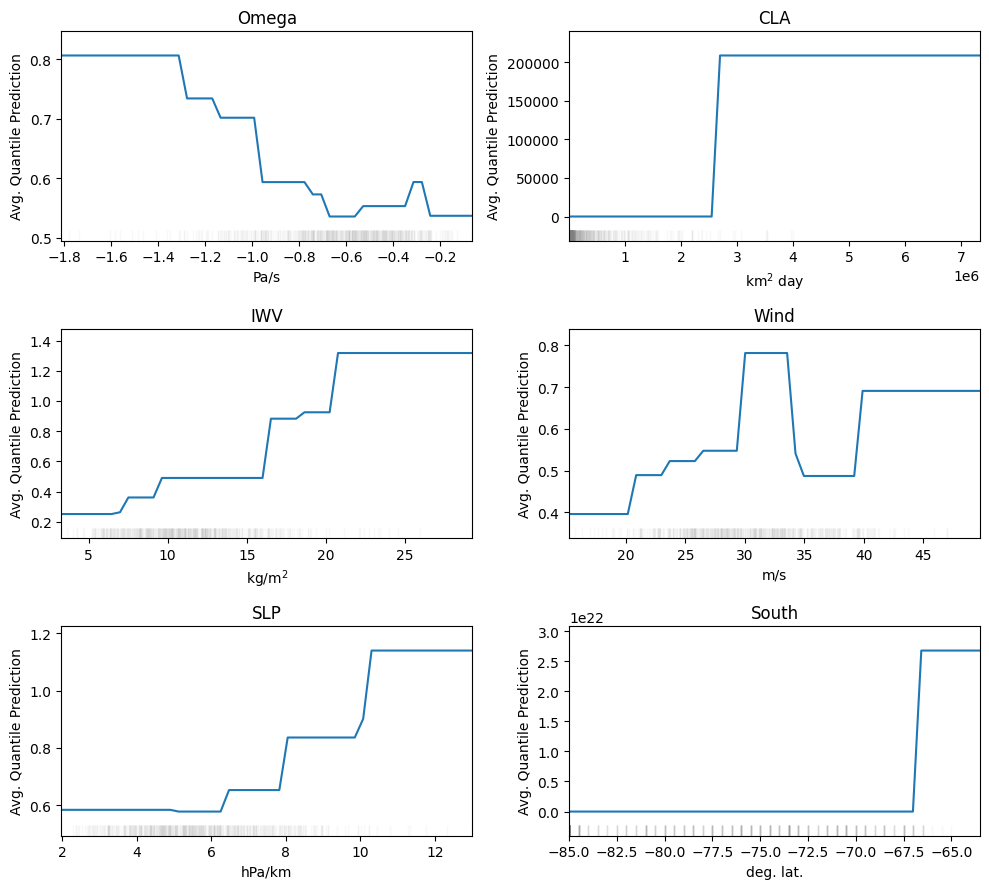

In [4]:
pdp_1D_dir = load_path / 'pdp_1D'
snow_files = sorted(pdp_1D_dir.glob('*snow.csv'))

n = len(snow_files)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows))
axs = np.atleast_1d(axs).flatten()

for ax, fpath in zip(axs, snow_files):
    df = pd.read_csv(fpath)

    # the grid column is whatever isn't 'Q' (ignore any saved index column)
    var = next(c for c in df.columns if c != 'Q' and not c.startswith('Unnamed'))

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    df = df.sort_values(var)  # ensure the line plots left-to-right

    plot_pdp_1d(grid=df[var], pdp_vals=df['Q'], ax=ax, title=abbv, feature_values=X_full_snow[var], 
                xlabel=units, ylabel='Avg. Quantile Prediction', rug=True);

# hide any leftover empty axes (e.g. if n isn't a multiple of ncols)
for ax in axs[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_snow_1D_pdp_full_unfiltered.png', dpi=300)

We will clip the PDPs because of the extremely high predictions. We'll clip for both the full set of plots, as well as a subset.

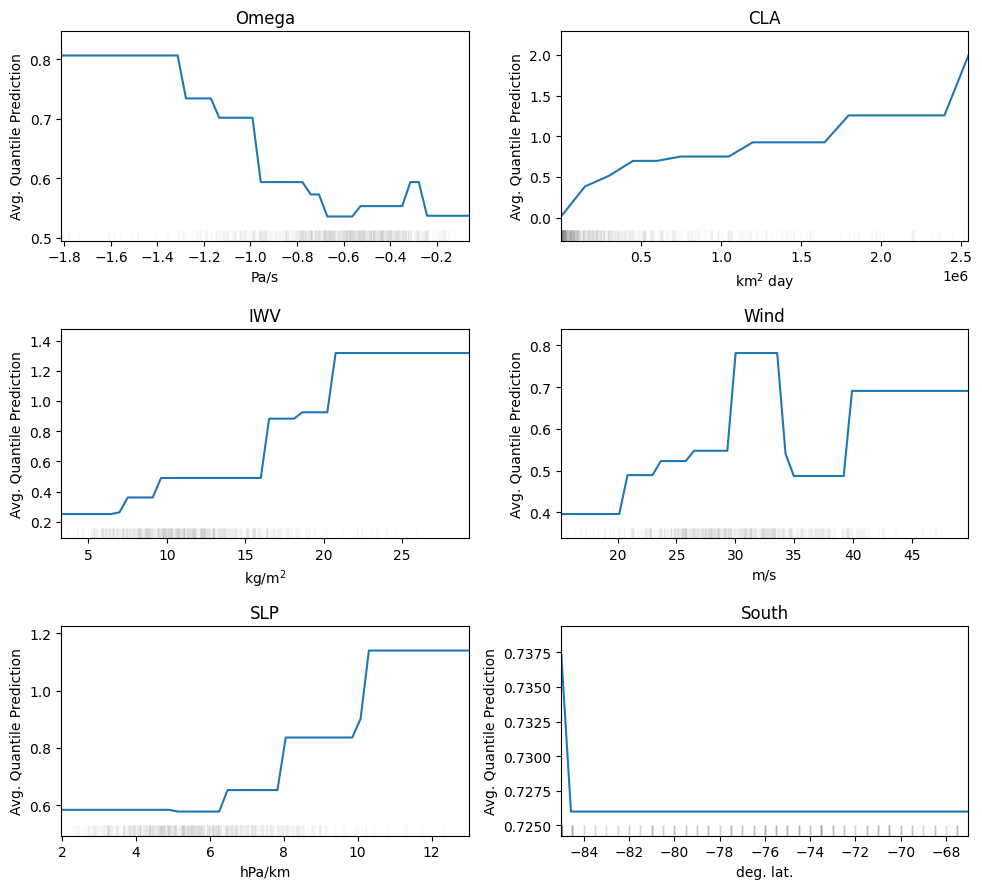

In [5]:
pdp_1D_dir = load_path / 'pdp_1D'
snow_files = sorted(pdp_1D_dir.glob('*snow.csv'))

n = len(snow_files)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows))
axs = np.atleast_1d(axs).flatten()

for ax, fpath in zip(axs, snow_files):
    df = pd.read_csv(fpath)

    if 'cumulative_landfalling_area' in df.columns or 'max_south_extent' in df.columns:
        df = df.loc[df.Q <= 100]

    # the grid column is whatever isn't 'Q' (ignore any saved index column)
    var = next(c for c in df.columns if c != 'Q' and not c.startswith('Unnamed'))

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    df = df.sort_values(var)  # ensure the line plots left-to-right

    plot_pdp_1d(grid=df[var], pdp_vals=df['Q'], ax=ax, title=abbv, feature_values=X_full_snow[var], 
                xlabel=units, ylabel='Avg. Quantile Prediction', rug=True);

# hide any leftover empty axes (e.g. if n isn't a multiple of ncols)
for ax in axs[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_snow_1D_pdp_full_filtered.png', dpi=300)

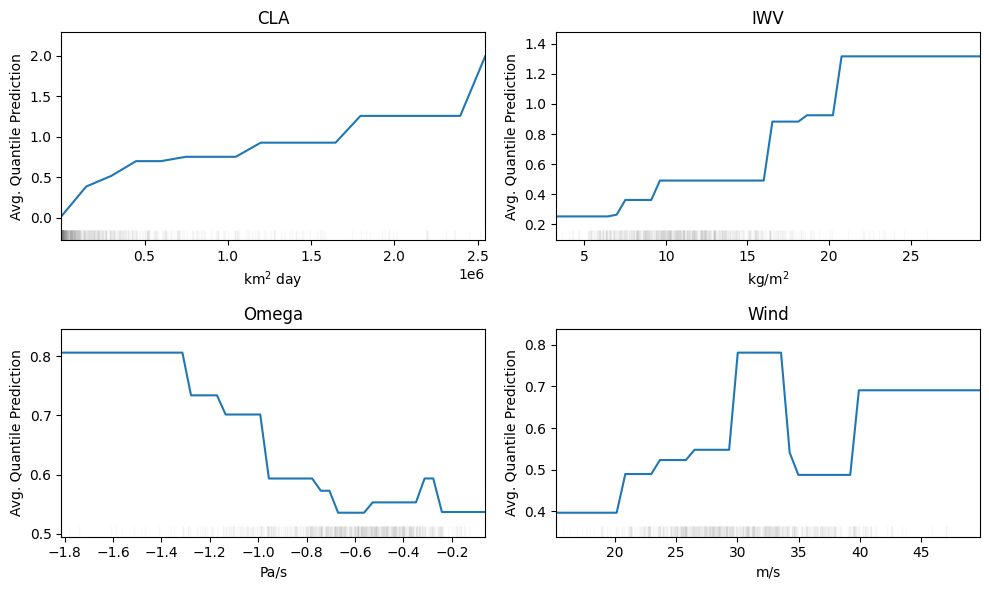

In [6]:
wanted = ['cumulative_landfalling_area',
          'max_IWV_ais',
          'avg_landfalling_minomega',
          'max_landfalling_v850hPa'] 

snow_files = [pdp_1D_dir / f'{v}_995_snow.csv' for v in wanted]

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs = np.atleast_1d(axs).flatten()

for ax, fpath in zip(axs, snow_files):
    df = pd.read_csv(fpath)

    if 'cumulative_landfalling_area' in df.columns:
        df = df.loc[df.Q <= 100]

    # the grid column is whatever isn't 'Q' (ignore any saved index column)
    var = next(c for c in df.columns if c != 'Q' and not c.startswith('Unnamed'))

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    df = df.sort_values(var)  # ensure the line plots left-to-right

    plot_pdp_1d(grid=df[var], pdp_vals=df['Q'], ax=ax, title=abbv, feature_values=X_full_snow[var], 
                xlabel=units, ylabel='Avg. Quantile Prediction', rug=True);

# hide any leftover empty axes (e.g. if n isn't a multiple of ncols)
for ax in axs[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_snow_1D_pdp_subset_filtered.png', dpi=300)

Now, let's look at 2D partial dependence plots.

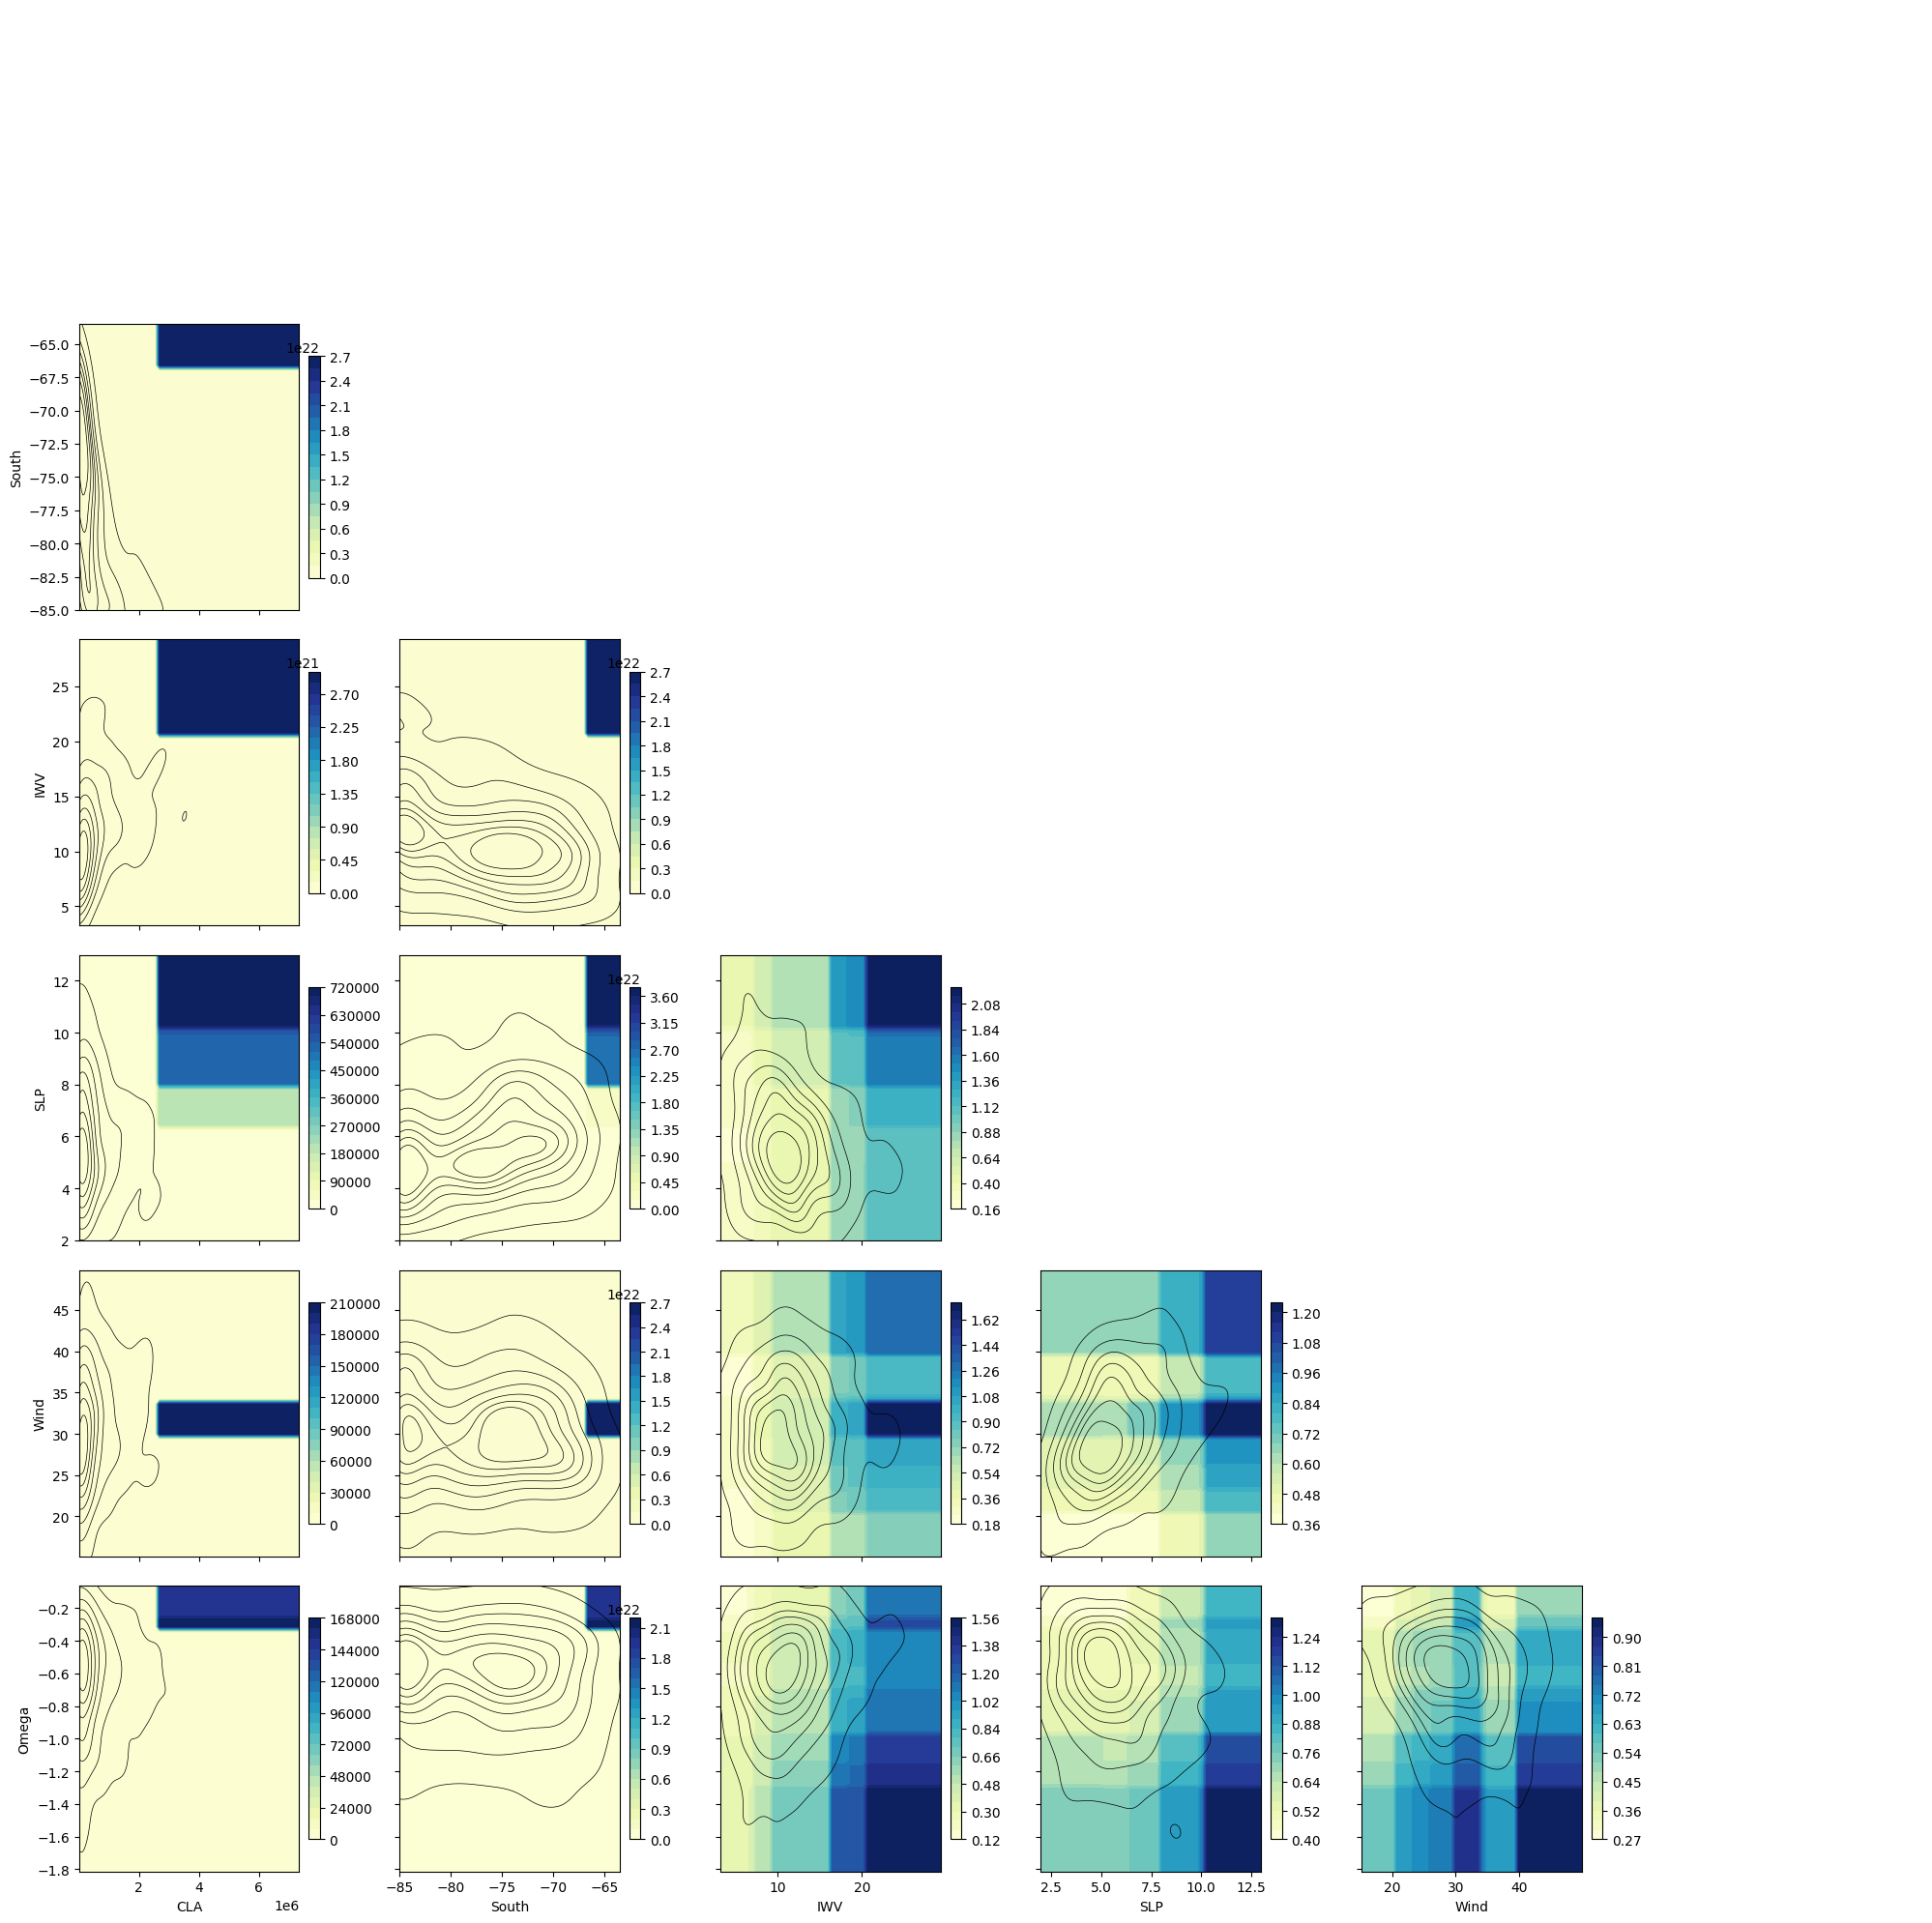

In [7]:
pdp_2D_dir = load_path / 'pdp_2D'
snow_files = sorted(pdp_2D_dir.glob('*snow*.csv'))

# Map each unordered variable pair to its file for efficient plotting
pair_to_file = {}
for f in snow_files:
    cols = [c for c in pd.read_csv(f, nrows=0).columns
            if c != 'Q' and not c.startswith('Unnamed')]
    pair_to_file[frozenset(cols)] = f

features = list(X_full_snow.columns)
n_features = len(features)

fig, axs = plt.subplots(ncols=n_features, nrows=n_features, figsize=(20, 20))

for i in range(n_features):
    for j in range(n_features):
        ax = axs[i, j]
        # lower triangle only
        if i > j:
            feat_y = features[i]
            feat_x = features[j]
            key = frozenset({feat_x, feat_y})

            if key not in pair_to_file:
                ax.axis('off')
                continue
            df = pd.read_csv(pair_to_file[key])
            # pivot to a grid; rows = y feature, cols = x feature.
            # Pivoting by the DESIRED roles handles whichever order the file stored them.
            piv = df.pivot_table(index=feat_y, columns=feat_x, values='Q')
            grid1 = piv.columns.values          # x grid
            grid2 = piv.index.values            # y grid
            pdp_matrix = piv.values             # shape (len(grid2), len(grid1))

            ax, cf = plot_pdp_2d(grid1, grid2, pdp_matrix, ax, feat_x_values=X_full_snow[feat_x],
                feat_y_values=X_full_snow[feat_y], cmap='YlGnBu', levels=25, kde=True)

            fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

            # standardize labels: x only on bottom row, y only on left column
            if i == n_features - 1:
                ax.set_xlabel(ABBV_DICT.get(feat_x, feat_x))
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(ABBV_DICT.get(feat_y, feat_y))
            else:
                ax.set_ylabel('')
                ax.set_yticklabels([])

        else:
            ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_snow_2D_pdp_full_unfiltered.png', dpi=300);

Like before, let's clip the CLA and South plots so we can actually see some patterns.

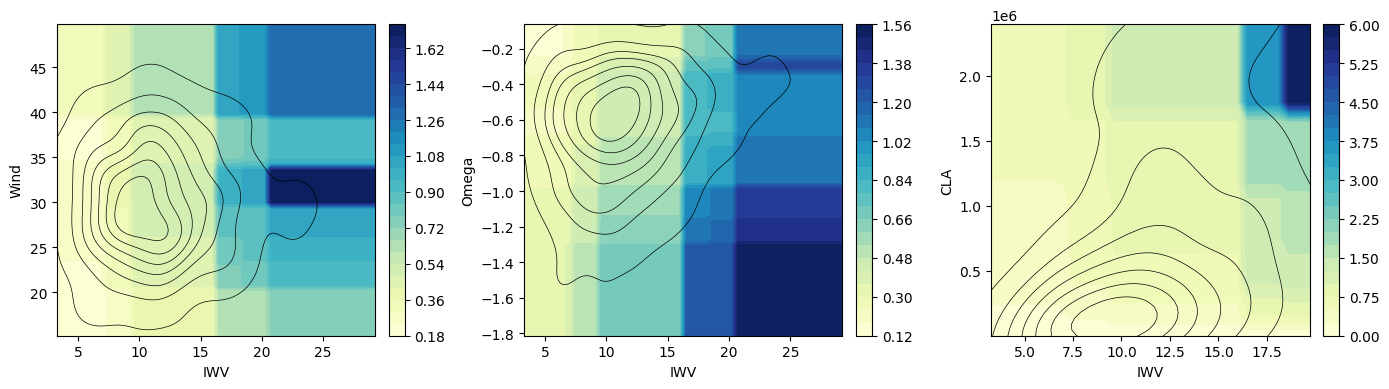

In [8]:
pdp_2D_dir = load_path / 'pdp_2D'
snow_files = sorted(pdp_2D_dir.glob('*snow*.csv'))

# Map each unordered variable pair to its file
pair_to_file = {}
for f in snow_files:
    cols = [c for c in pd.read_csv(f, nrows=0).columns
            if c != 'Q' and not c.startswith('Unnamed')]
    pair_to_file[frozenset(cols)] = f

# specify the three pairs to plot, as (x_feature, y_feature)
combos = [
    ('max_IWV_ais', 'max_landfalling_v850hPa'),
    ('max_IWV_ais', 'avg_landfalling_minomega'),
    ('max_IWV_ais', 'cumulative_landfalling_area'),
]

fig, axs = plt.subplots(ncols=len(combos), nrows=1, figsize=(14, 4))
axs = np.atleast_1d(axs)   # keep it iterable even for a single combo

for ax, (feat_x, feat_y) in zip(axs, combos):
    key = frozenset({feat_x, feat_y})
    if key not in pair_to_file:
        ax.axis('off')
        continue

    df = pd.read_csv(pair_to_file[key])

    if 'cumulative_landfalling_area' in df.columns:
       df = df.loc[(df.max_IWV_ais <= 20) & (df.cumulative_landfalling_area <= 2.5*(10**6))]
    
    piv = df.pivot_table(index=feat_y, columns=feat_x, values='Q')
    grid1 = piv.columns.values
    grid2 = piv.index.values
    pdp_matrix = piv.values

    ax, cf = plot_pdp_2d(grid1, grid2, pdp_matrix, ax,
                         feat_x_values=X_full_snow[feat_x],
                         feat_y_values=X_full_snow[feat_y],
                         cmap='YlGnBu', levels=25, kde=True)
    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xlabel(ABBV_DICT.get(feat_x, feat_x))
    ax.set_ylabel(ABBV_DICT.get(feat_y, feat_y))

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_snow_2D_pdp_subset_filtered.png', dpi=300);

We conclude this analysis by examining SHAP values.

In [9]:
shap_snow = pd.read_csv(load_path / 'shap/snow_shap_values.csv')

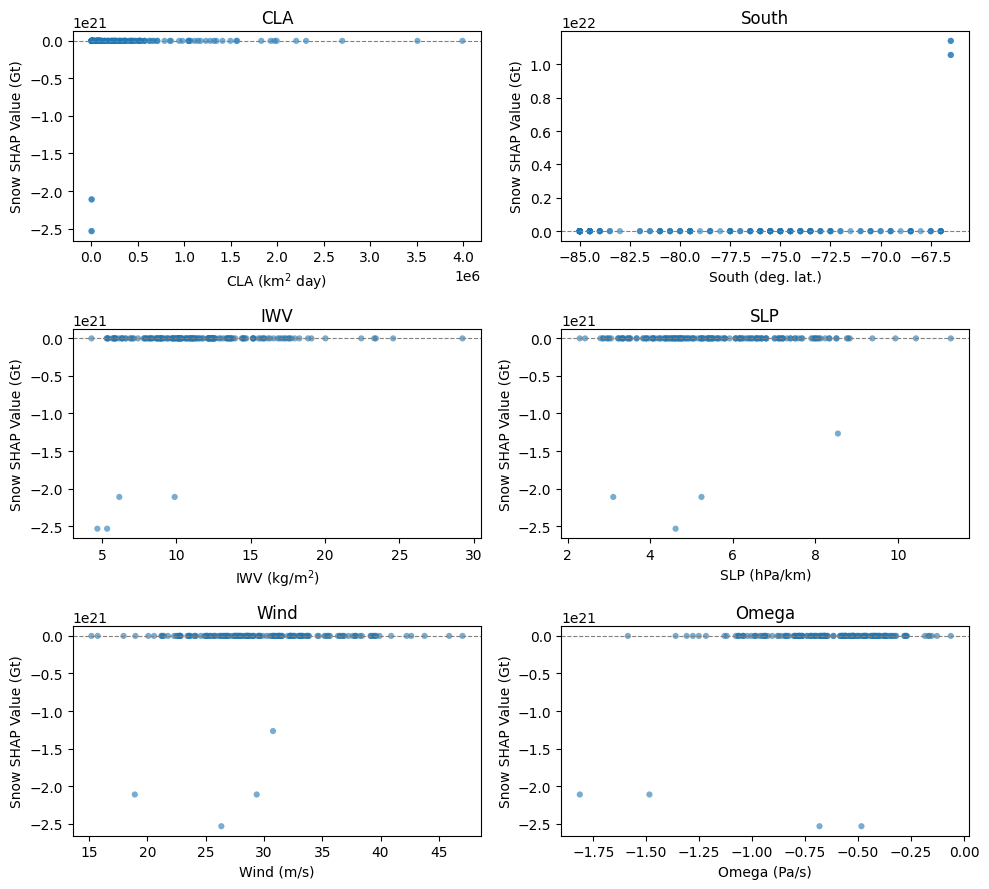

In [10]:
features = list(shap_snow.columns)
n = len(features)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows))
axes = np.atleast_1d(axes).flatten()

for ax, feat in zip(axes, features):
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')

    plot_shap_dependence(shap_values=shap_snow, feature_values=X_test_snow, feature=feat,
        ax=ax, title=abbv, xlabel=f'{abbv} ({units})' if units else abbv,
        ylabel='Snow SHAP Value (Gt)')

# blank any leftover axes if n isn't a multiple of ncols
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_snow_1D_shap_full_unfiltered.png', dpi=300)

There's quite a few extreme SHAP values which make it difficult to observe some of the finer relationships. Let's clip these plots so we can see what the smaller SHAP values look like.

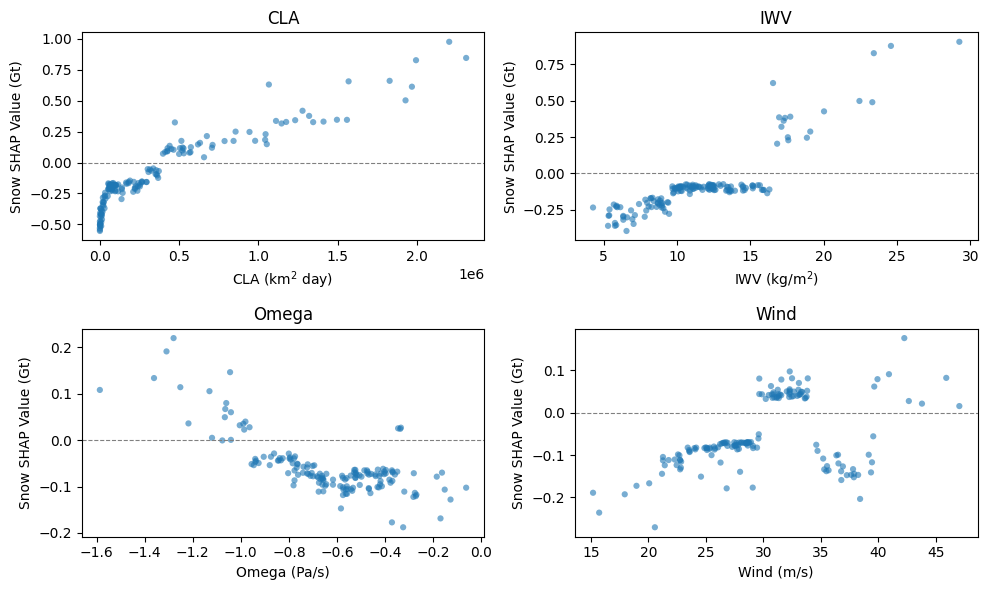

In [11]:
wanted = ['cumulative_landfalling_area', 'max_IWV_ais', 'avg_landfalling_minomega', 'max_landfalling_v850hPa']
to_clip = ~(shap_snow >= 100).any(axis=1)
shap_snow_clipped = shap_snow[to_clip]
X_test_snow_clipped = X_test_snow[to_clip]
shap_snow_clipped_subset = shap_snow_clipped[wanted]

features = list(shap_snow_clipped_subset.columns)
n = len(features)
ncols = 2
nrows = int(np.ceil(n / ncols))

shap_snow

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 6))
axes = np.atleast_1d(axes).flatten()

for ax, feat in zip(axes, features):
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')

    plot_shap_dependence(shap_values=shap_snow_clipped_subset, feature_values=X_test_snow_clipped[wanted], feature=feat,
        ax=ax, title=abbv, xlabel=f'{abbv} ({units})' if units else abbv,
        ylabel='Snow SHAP Value (Gt)')

# blank any leftover axes if n isn't a multiple of ncols
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()

plt.savefig('../outputs/plots/extreme_snow_1D_shap_subset_filtered.png', dpi=300)

Patterns are a little bit easier to see here! However, these SHAP values are gigantic!

In [12]:
shap_snow.abs().max()

cumulative_landfalling_area    2.534165e+21
max_south_extent               1.140345e+22
max_IWV_ais                    2.534165e+21
max_ocean_SLP_gradient         2.533909e+21
max_landfalling_v850hPa        2.534065e+21
avg_landfalling_minomega       2.534165e+21
dtype: float64

In [13]:
shap_snow.min()

cumulative_landfalling_area   -2.534165e+21
max_south_extent              -6.876606e+08
max_IWV_ais                   -2.534165e+21
max_ocean_SLP_gradient        -2.533909e+21
max_landfalling_v850hPa       -2.534065e+21
avg_landfalling_minomega      -2.534165e+21
dtype: float64

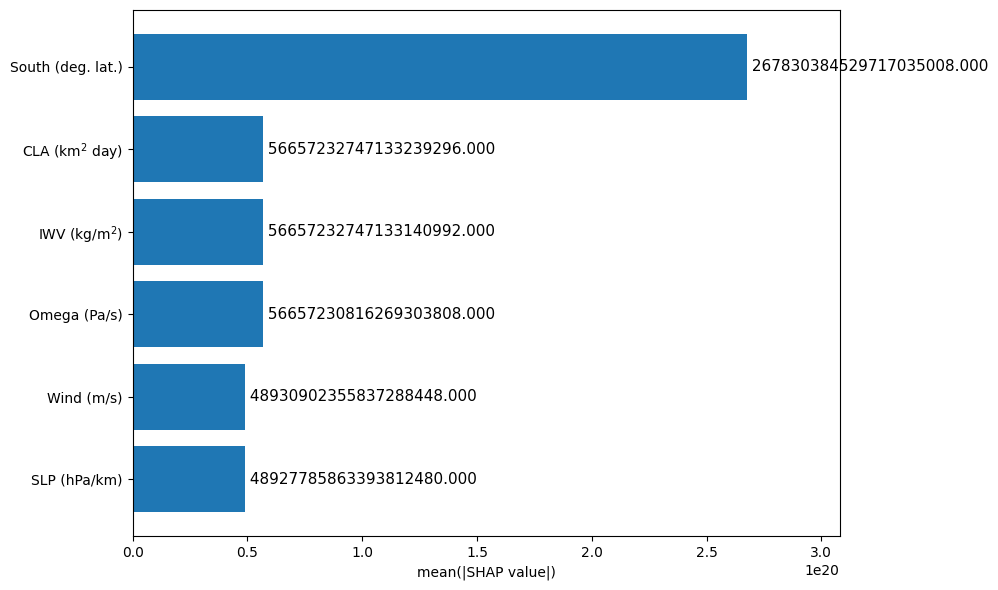

In [14]:
# make pretty tick labels!
tick_labels = []
for feat in shap_snow.columns:
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')
    tick_labels.append(f'{abbv} ({units})' if units else abbv)

fig, ax = plt.subplots(figsize=(10, 6))
plot_shap_summary_bar(shap_snow, ax, tick_labels=tick_labels, xlabel='mean(|SHAP value|)')
plt.tight_layout()

It seems like southern extent is the dominant variable. There's a few ARs for which, for some reason, the predictions for snowfall quantiles are extremely large.

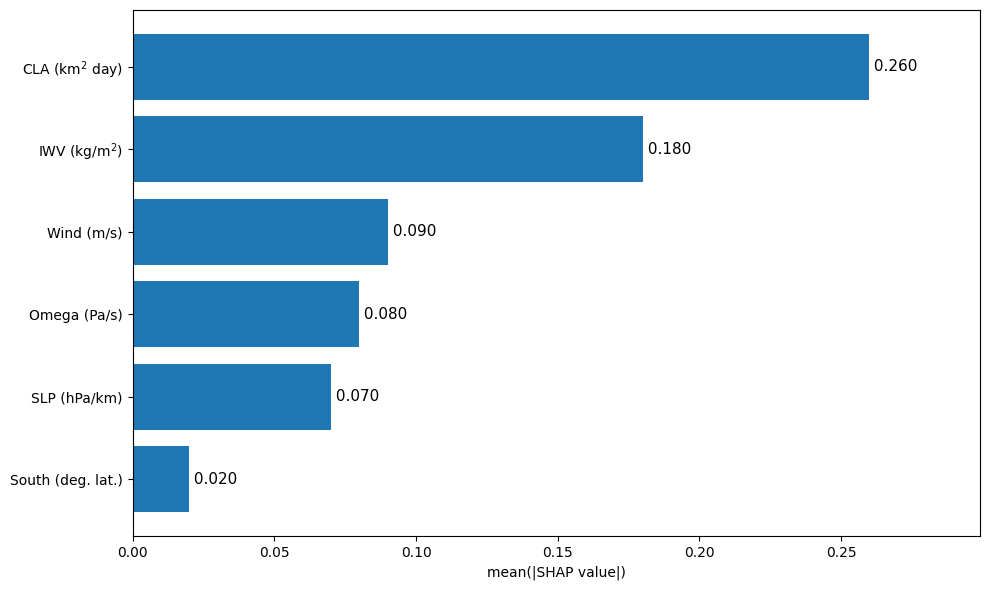

In [15]:
tick_labels = []
for feat in shap_snow_clipped.columns:
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')
    tick_labels.append(f'{abbv} ({units})' if units else abbv)

fig, ax = plt.subplots(figsize=(10, 6))
plot_shap_summary_bar(shap_snow_clipped, ax, tick_labels=tick_labels, xlabel='mean(|SHAP value|)',
)
plt.tight_layout()

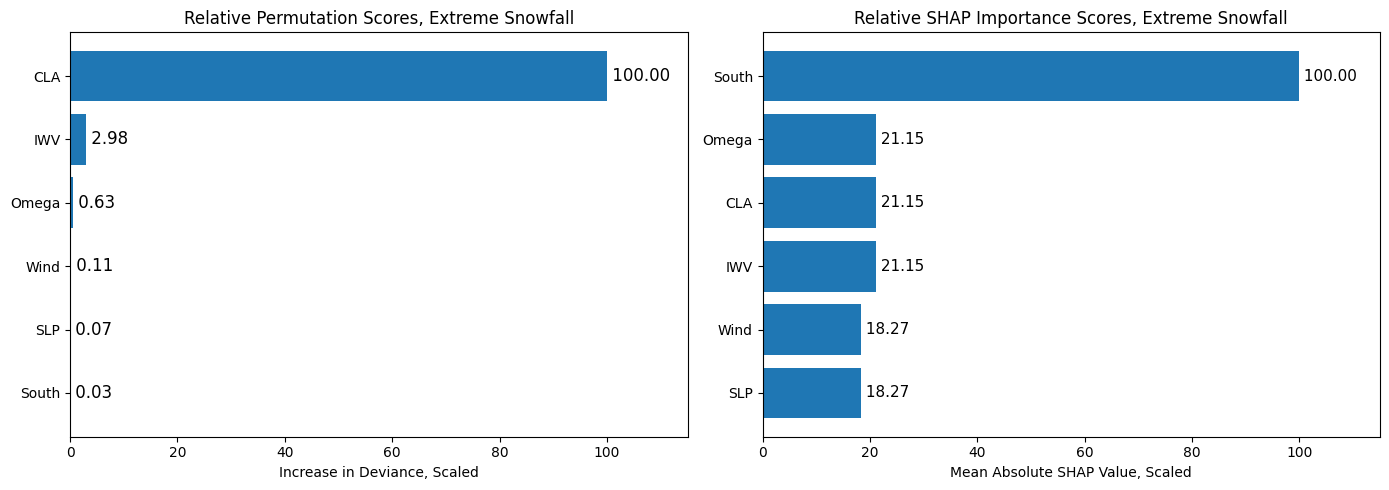

In [16]:
fig, axs = plt.subplots(figsize=(14,5), ncols=2, nrows=1)
tick_labels = [ABBV_DICT[varname] for varname in snow_VI_dat.index]
plot_variable_importance(snow_VI_dat, axs[0], 'Relative Permutation Scores, Extreme Snowfall', value_col='avg_perm_diff', 
                         xlabel = 'Increase in Deviance, Scaled', normalize=True, tick_labels=tick_labels)

tick_labels = []
for feat in X_test_snow.columns:
    abbv = ABBV_DICT.get(feat, feat)
    tick_labels.append(f'{abbv}' if units else abbv)
plot_shap_summary_bar(shap_snow, axs[1], tick_labels=tick_labels, 
                      feature_names=X_test_snow.columns, title='Relative SHAP Importance Scores, Extreme Snowfall', 
                      xlabel='Mean Absolute SHAP Value, Scaled', normalize=True,
                      label_fmt='{:.2f}')
plt.tight_layout()
plt.savefig('../outputs/plots/extreme_snowfall_VI.png', dpi=300);

## Temperature

Now, we run through the results for maximum 2m-temperature anomaly.

In [17]:
# load snowfall datasets

X_full_temp = pd.read_csv(load_path / 'train_test_data/gbex_temp_fullX.csv')
z_full_temp = pd.read_csv(load_path / 'train_test_data/gbex_temp_fullZ.csv')
X_train_temp = pd.read_csv(load_path / 'train_test_data/gbex_temp_trainX.csv')
z_train_temp = pd.read_csv(load_path / 'train_test_data/gbex_temp_trainZ.csv')
X_test_temp = pd.read_csv(load_path / 'train_test_data/gbex_temp_testX.csv')
z_test_temp = pd.read_csv(load_path / 'train_test_data/gbex_temp_testZ.csv')

One of the permutation differences is actually negative, indicating that shuffling the data actually improved the model prediction. Let's clip this column to 0 as the lower bound, since any slightly negative permutation difference indicates that variable is not important at all.

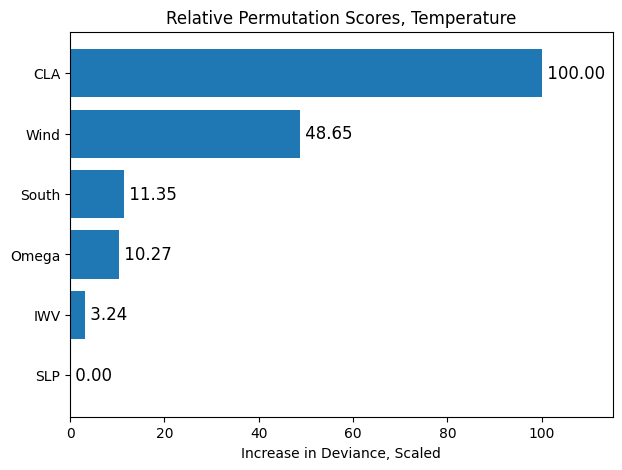

In [18]:
temp_VI_dat = pd.read_csv(load_path / 'variable_importance/temp_gbex_VI.csv', index_col=0)
temp_VI_dat = temp_VI_dat.clip(lower=0)
temp_VI_dat = temp_VI_dat.round(4)
temp_VI_dat = temp_VI_dat.sort_values(by='avg_perm_diff', ascending=False)
tick_labels = [ABBV_DICT[varname] for varname in temp_VI_dat.index]

fig, ax = plt.subplots(figsize=(7,5))
plot_variable_importance(importances=temp_VI_dat, ax=ax, value_col='avg_perm_diff', 
                        title='Relative Permutation Scores, Temperature', xlabel='Increase in Deviance, Scaled', normalize=True, tick_labels=tick_labels);

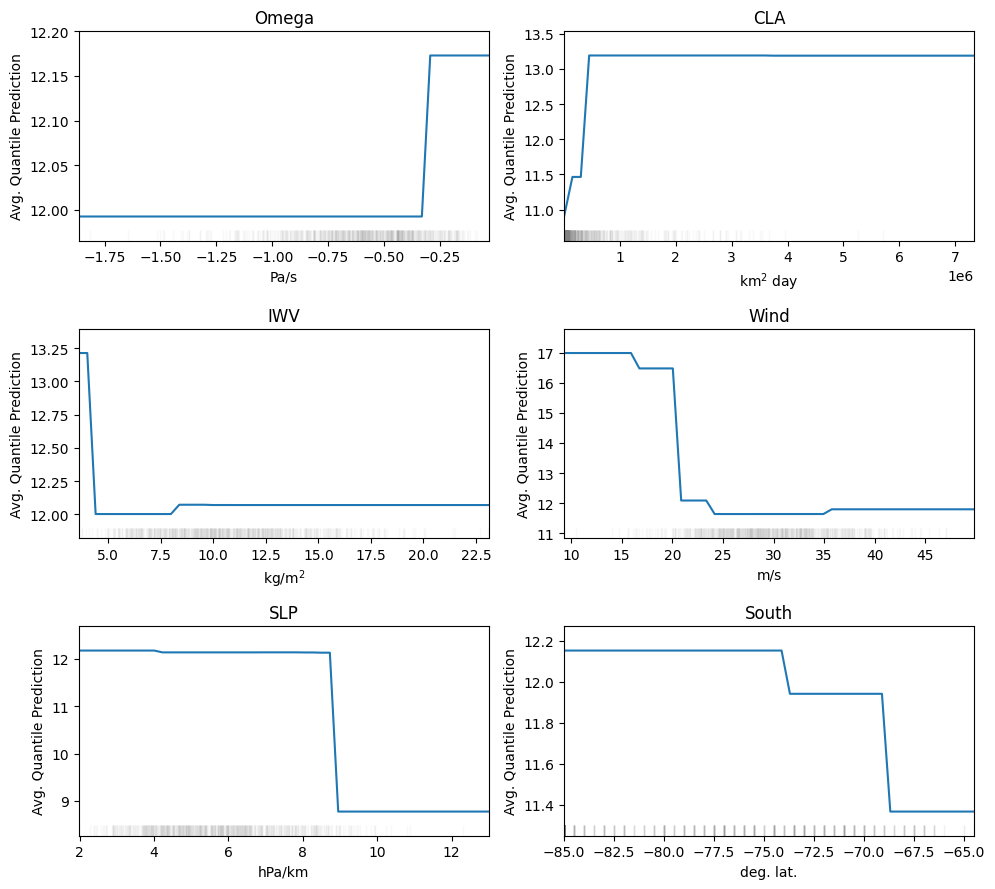

In [19]:
pdp_1D_dir = load_path / 'pdp_1D'
temp_files = sorted(pdp_1D_dir.glob('*temp.csv'))

n = len(temp_files)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows))
axs = np.atleast_1d(axs).flatten()

for ax, fpath in zip(axs, temp_files):
    df = pd.read_csv(fpath)

    # the grid column is whatever isn't 'Q' (ignore any saved index column)
    var = next(c for c in df.columns if c != 'Q' and not c.startswith('Unnamed'))

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    df = df.sort_values(var)  # ensure the line plots left-to-right

    plot_pdp_1d(grid=df[var], pdp_vals=df['Q'], ax=ax, title=abbv, feature_values=X_full_temp[var], 
                xlabel=units, ylabel='Avg. Quantile Prediction', rug=True,
                rug_kwargs={'height': 0.05, 'color': 'gray', 'alpha': 0.05})

# hide any leftover empty axes (e.g. if n isn't a multiple of ncols)
for ax in axs[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_temp_1D_pdp_full.png', dpi=300)

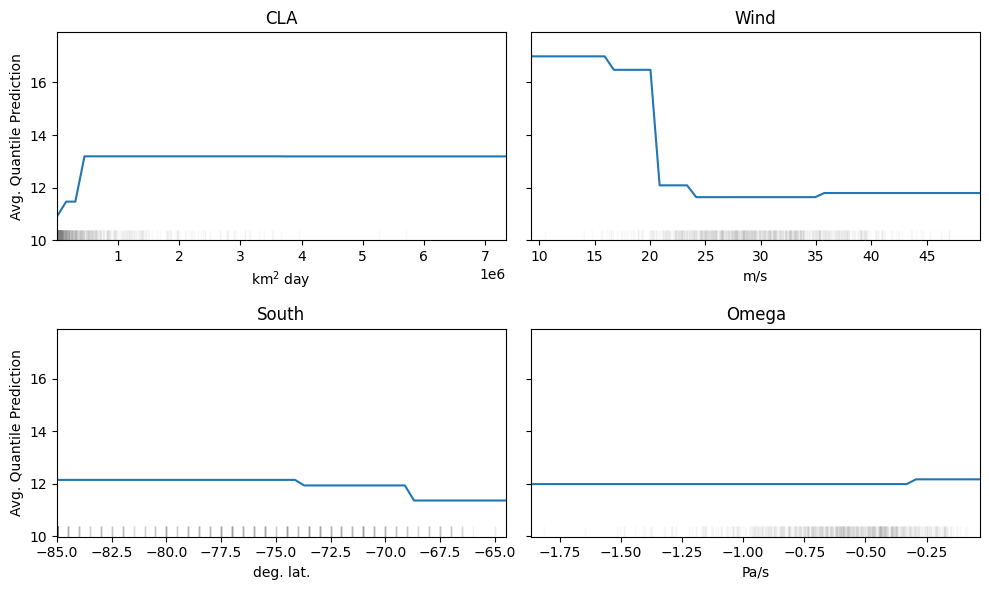

In [20]:
wanted = ['cumulative_landfalling_area',
          'max_landfalling_v850hPa',
          'max_south_extent',
          'avg_landfalling_minomega'] 

temp_files = [pdp_1D_dir / f'{v}_995_temp.csv' for v in wanted]

fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)
axs = np.atleast_1d(axs).flatten()

for ax, fpath in zip(axs, temp_files):
    df = pd.read_csv(fpath)

    # the grid column is whatever isn't 'Q' (ignore any saved index column)
    var = next(c for c in df.columns if c != 'Q' and not c.startswith('Unnamed'))

    # grab variable name abbreviation and units for labelling
    abbv = ABBV_DICT[var]
    units = UNITS_DICT[var]

    df = df.sort_values(var)  # ensure the line plots left-to-right

    plot_pdp_1d(grid=df[var], pdp_vals=df['Q'], ax=ax, title=abbv, feature_values=X_full_temp[var], 
                xlabel=units, ylabel='Avg. Quantile Prediction', rug=True);

# hide any leftover empty axes (e.g. if n isn't a multiple of ncols)
for ax in axs[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_temp_1D_pdp_subset.png', dpi=300)

Now, let's look at 2D partial dependence plots.

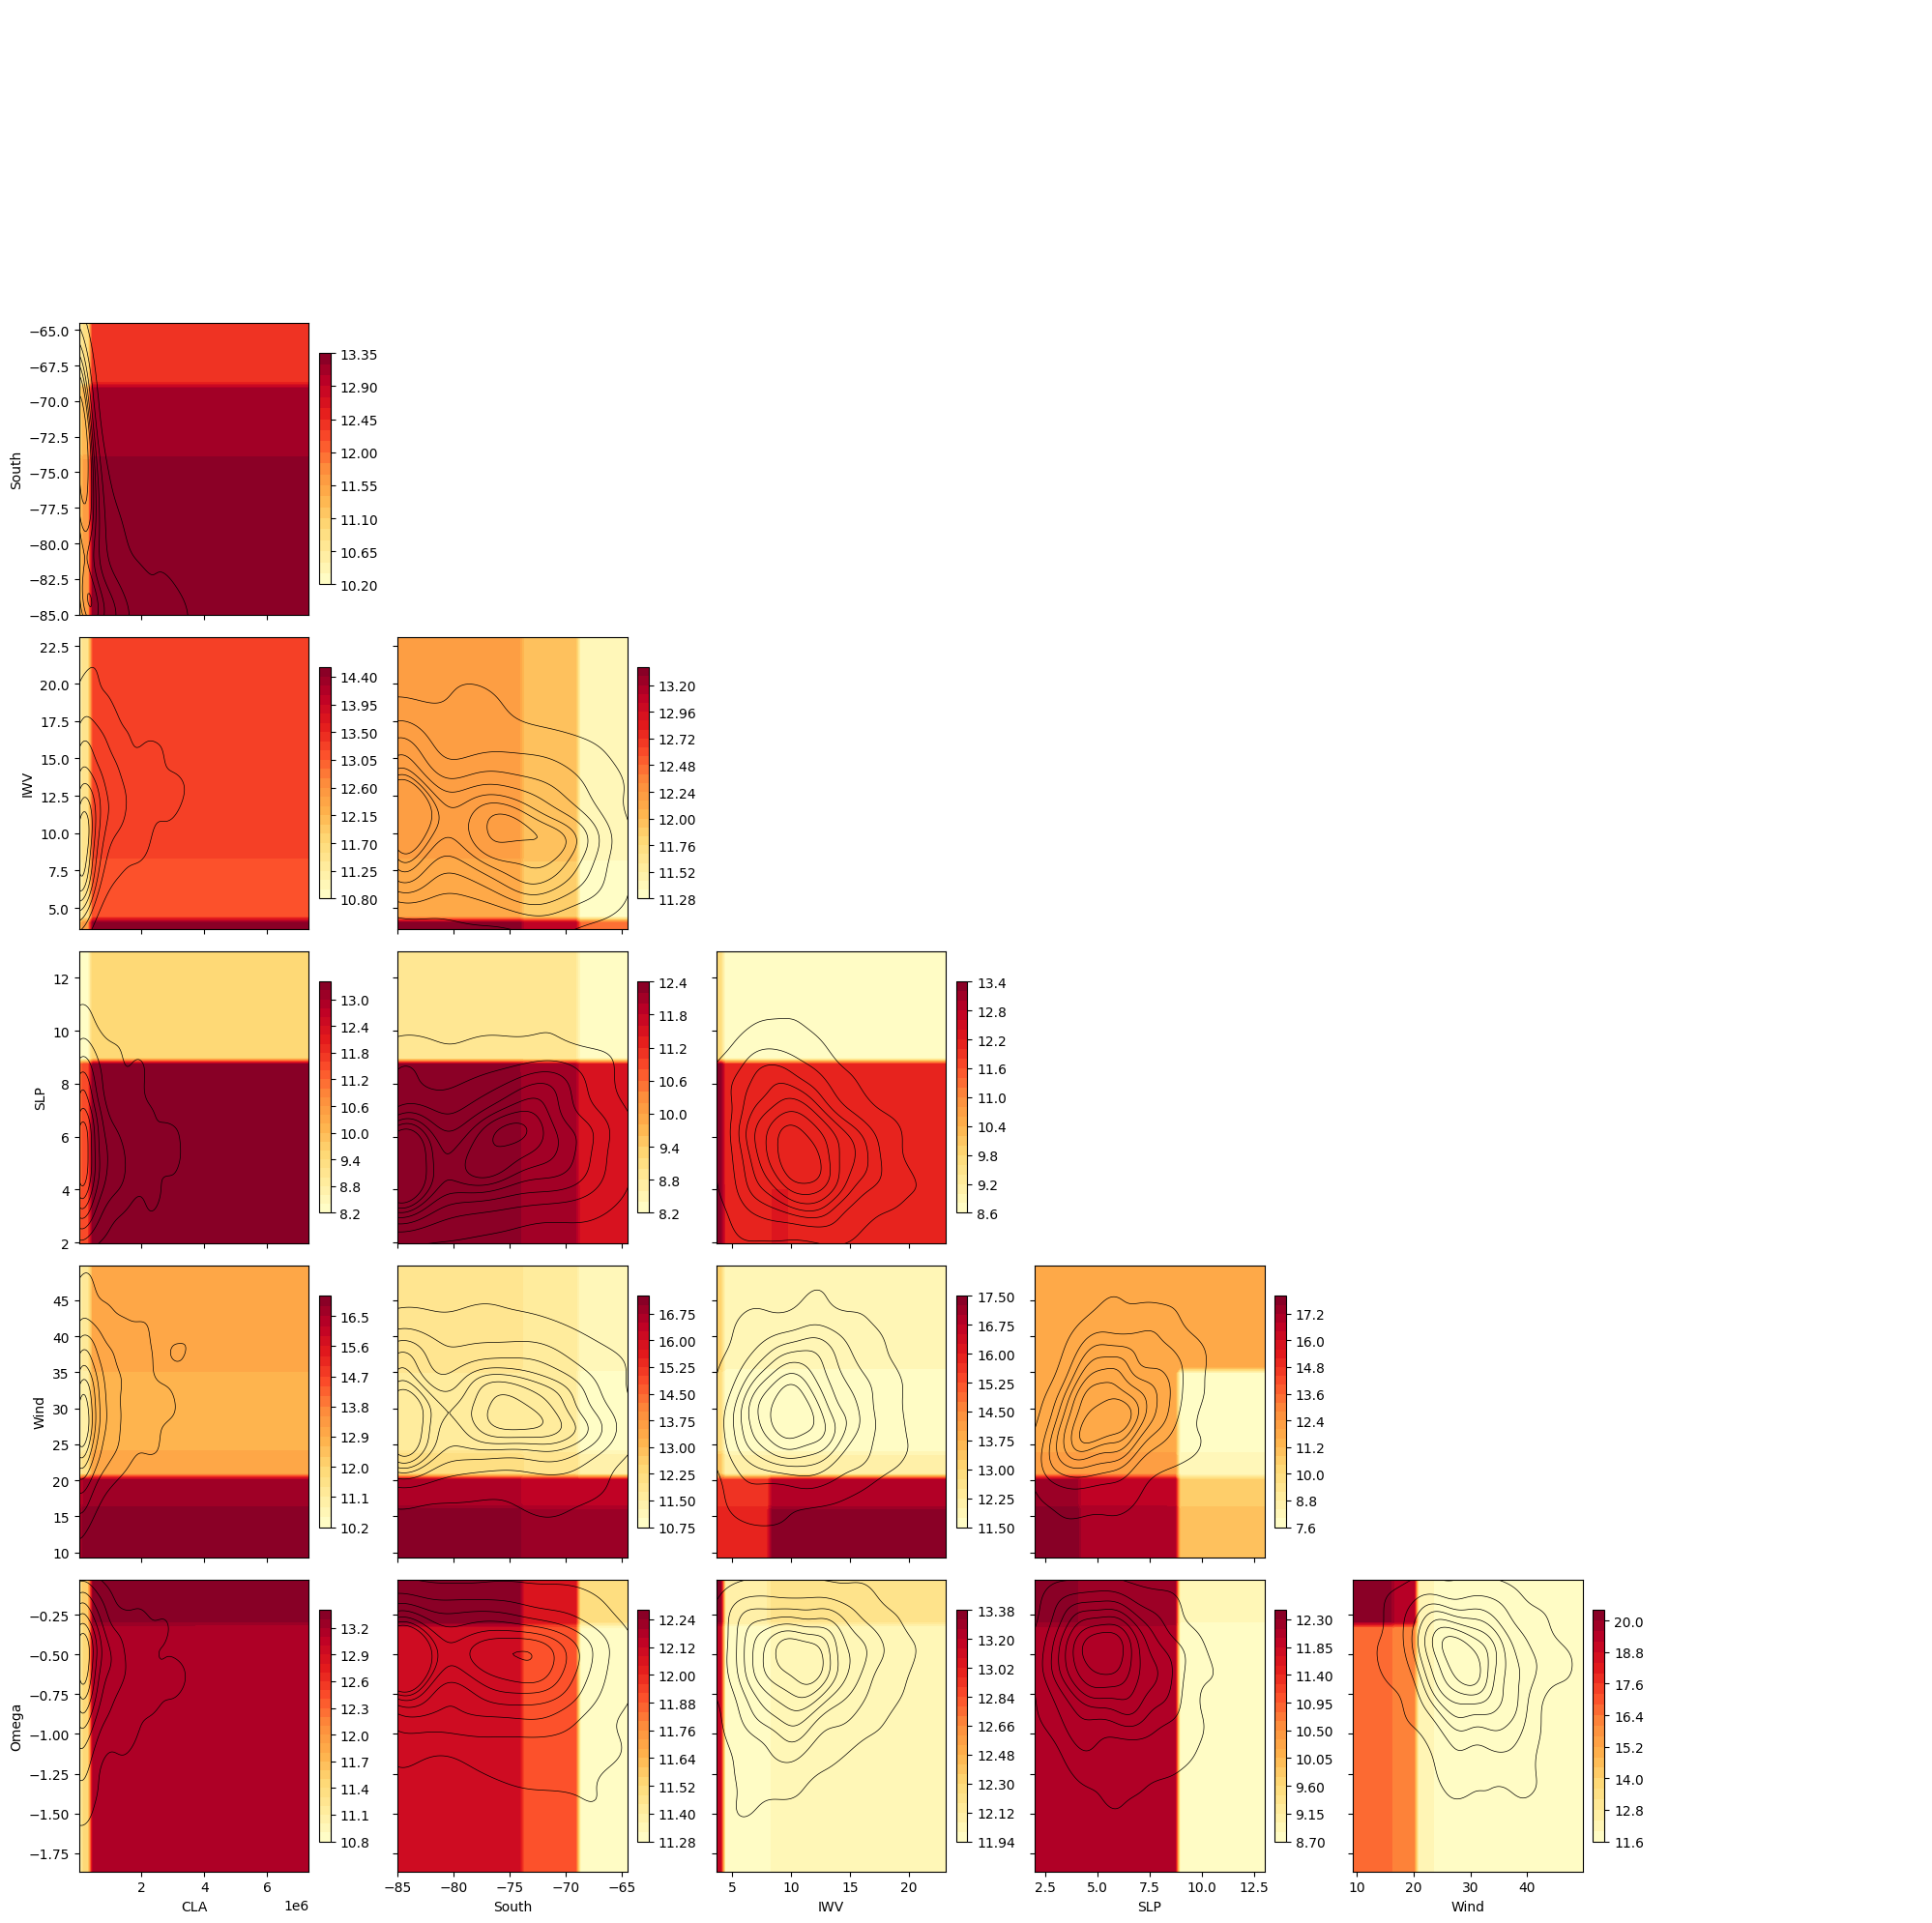

In [21]:
pdp_2D_dir = load_path / 'pdp_2D'
temp_files = sorted(pdp_2D_dir.glob('*temp.csv'))

# Map each unordered variable pair to its file for efficient plotting
pair_to_file = {}
for f in temp_files:
    cols = [c for c in pd.read_csv(f, nrows=0).columns
            if c != 'Q' and not c.startswith('Unnamed')]
    pair_to_file[frozenset(cols)] = f

features = list(X_full_temp.columns)
n_features = len(features)

fig, axs = plt.subplots(ncols=n_features, nrows=n_features, figsize=(20, 20))

for i in range(n_features):
    for j in range(n_features):
        ax = axs[i, j]
        # lower triangle only
        if i > j:
            feat_y = features[i]
            feat_x = features[j]
            key = frozenset({feat_x, feat_y})

            if key not in pair_to_file:
                ax.axis('off')
                continue
            df = pd.read_csv(pair_to_file[key])
            # pivot to a grid; rows = y feature, cols = x feature.
            # Pivoting by the DESIRED roles handles whichever order the file stored them.
            piv = df.pivot_table(index=feat_y, columns=feat_x, values='Q')
            grid1 = piv.columns.values          # x grid
            grid2 = piv.index.values            # y grid
            pdp_matrix = piv.values             # shape (len(grid2), len(grid1))

            ax, cf = plot_pdp_2d(grid1, grid2, pdp_matrix, ax, feat_x_values=X_full_temp[feat_x],
                feat_y_values=X_full_temp[feat_y], cmap='YlOrRd', levels=25, kde=True)

            fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

            # standardize labels: x only on bottom row, y only on left column
            if i == n_features - 1:
                ax.set_xlabel(ABBV_DICT.get(feat_x, feat_x))
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(ABBV_DICT.get(feat_y, feat_y))
            else:
                ax.set_ylabel('')
                ax.set_yticklabels([])

        else:
            ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_temp_2D_pdp_full.png', dpi=300);

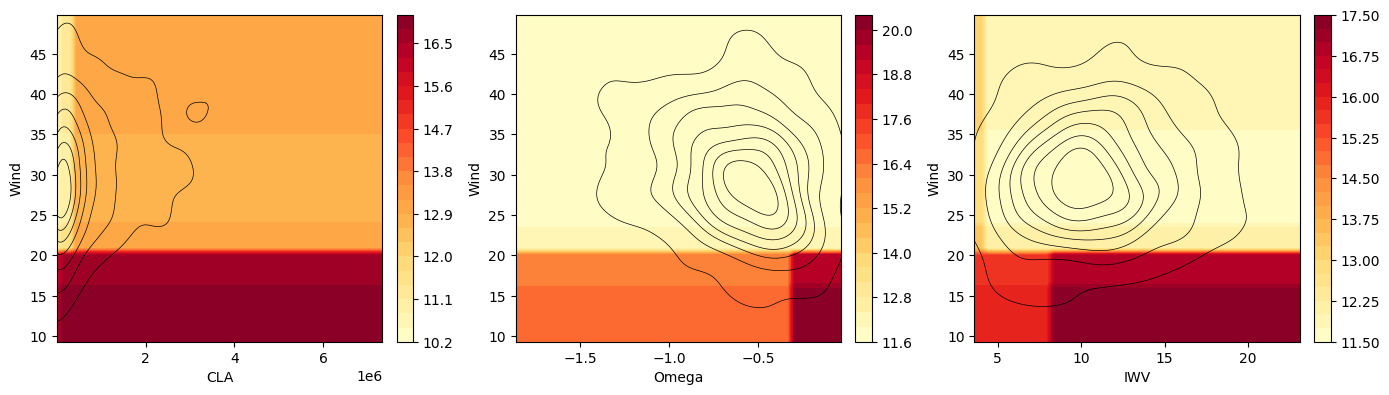

In [22]:
pdp_2D_dir = load_path / 'pdp_2D'
snow_files = sorted(pdp_2D_dir.glob('*temp*.csv'))

# Map each unordered variable pair to its file
pair_to_file = {}
for f in snow_files:
    cols = [c for c in pd.read_csv(f, nrows=0).columns
            if c != 'Q' and not c.startswith('Unnamed')]
    pair_to_file[frozenset(cols)] = f

# specify the three pairs to plot, as (x_feature, y_feature)
combos = [
    ('cumulative_landfalling_area', 'max_landfalling_v850hPa'),
    ('avg_landfalling_minomega', 'max_landfalling_v850hPa'),
    ('max_IWV_ais', 'max_landfalling_v850hPa'),
]

fig, axs = plt.subplots(ncols=len(combos), nrows=1, figsize=(14, 4))
axs = np.atleast_1d(axs)   # keep it iterable even for a single combo

for ax, (feat_x, feat_y) in zip(axs, combos):
    key = frozenset({feat_x, feat_y})
    if key not in pair_to_file:
        ax.axis('off')
        continue

    df = pd.read_csv(pair_to_file[key])
    piv = df.pivot_table(index=feat_y, columns=feat_x, values='Q')
    grid1 = piv.columns.values
    grid2 = piv.index.values
    pdp_matrix = piv.values

    ax, cf = plot_pdp_2d(grid1, grid2, pdp_matrix, ax,
                         feat_x_values=X_full_temp[feat_x],
                         feat_y_values=X_full_temp[feat_y],
                         cmap='YlOrRd', levels=25, kde=True)
    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xlabel(ABBV_DICT.get(feat_x, feat_x))
    ax.set_ylabel(ABBV_DICT.get(feat_y, feat_y))

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_temp_2D_pdp_subset.png', dpi=300);

We conclude this analysis by examining SHAP values.

In [23]:
shap_temp = pd.read_csv(load_path / 'shap/temp_shap_values.csv')

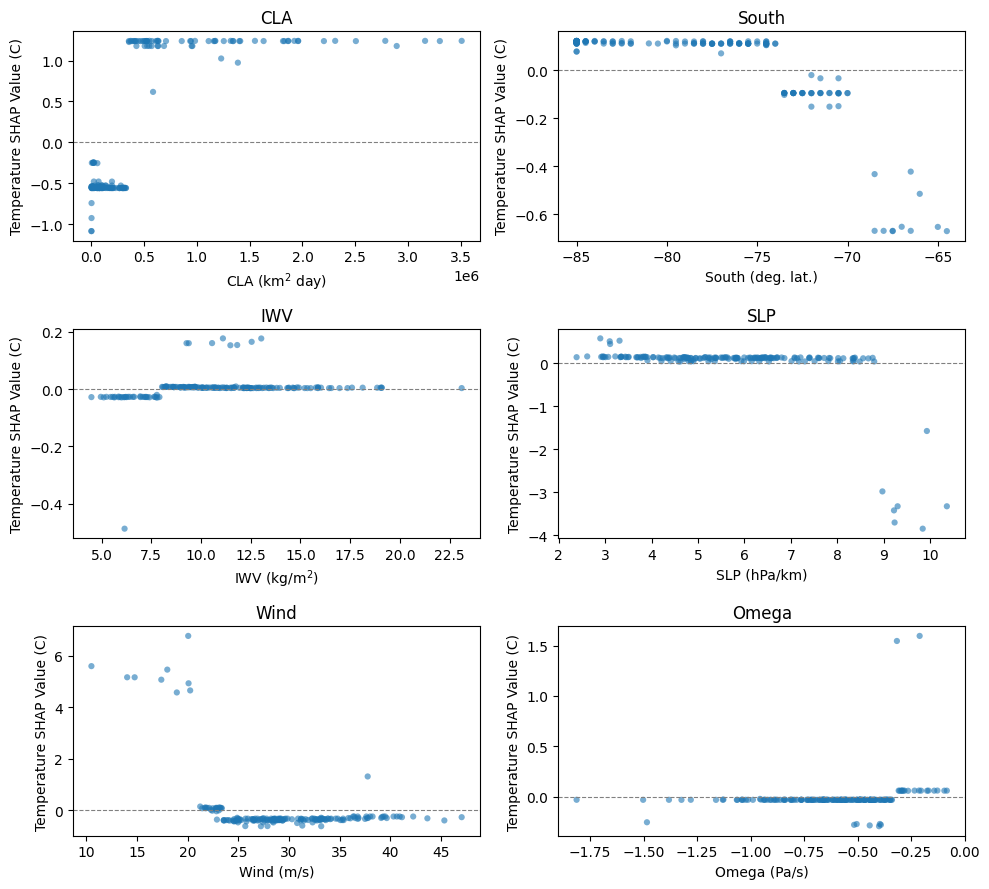

In [24]:
features = list(shap_temp.columns)
n = len(features)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows))
axes = np.atleast_1d(axes).flatten()

for ax, feat in zip(axes, features):
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')

    plot_shap_dependence(shap_values=shap_temp, feature_values=X_test_temp, feature=feat,
        ax=ax, title=abbv, xlabel=f'{abbv} ({units})' if units else abbv,
        ylabel='Temperature SHAP Value (C)')

# blank any leftover axes if n isn't a multiple of ncols
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_temp_1D_shap_full.png', dpi=300)

In [25]:
wanted = ['cumulative_landfalling_area', 'max_landfalling_v850hPa', 'max_south_extent', 'avg_landfalling_minomega', ]
shap_temp_subset = shap_temp[wanted]

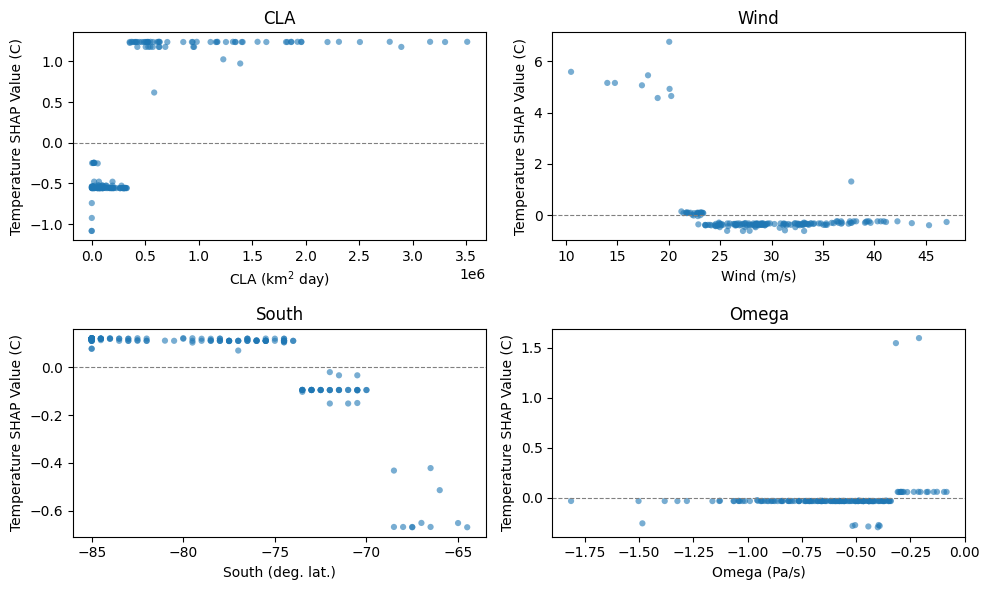

In [26]:
features = list(shap_temp_subset.columns)
n = len(features)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 6))
axes = np.atleast_1d(axes).flatten()

for ax, feat in zip(axes, features):
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')

    plot_shap_dependence(shap_values=shap_temp_subset, feature_values=X_test_temp[wanted], feature=feat,
        ax=ax, title=abbv, xlabel=f'{abbv} ({units})' if units else abbv,
        ylabel='Temperature SHAP Value (C)')

# blank any leftover axes if n isn't a multiple of ncols
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/plots/extreme_temp_1D_shap_subset.png', dpi=300)

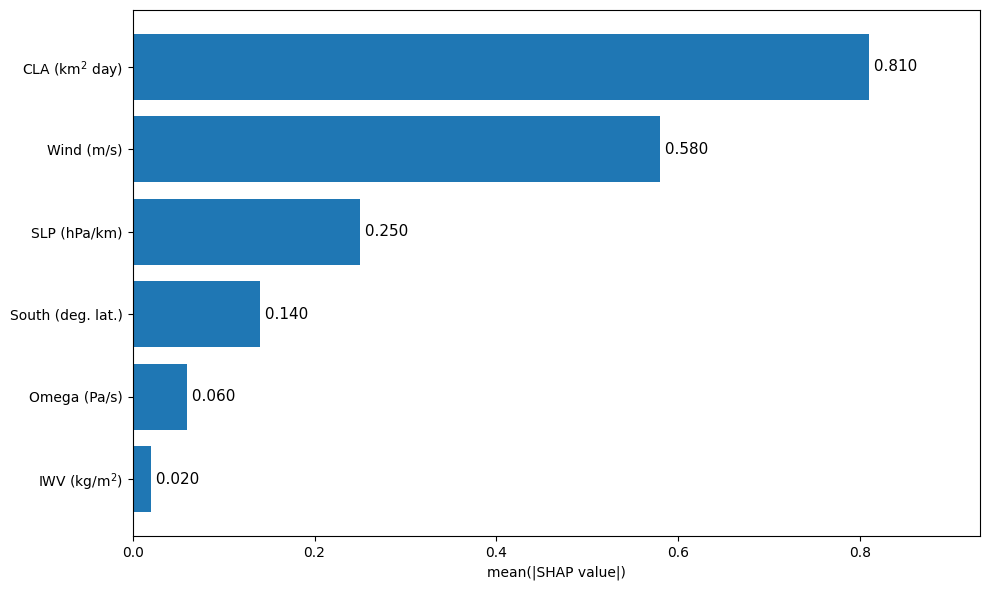

In [27]:
# make pretty tick labels!
tick_labels = []
for feat in shap_temp.columns:
    abbv = ABBV_DICT.get(feat, feat)
    units = UNITS_DICT.get(feat, '')
    tick_labels.append(f'{abbv} ({units})' if units else abbv)

fig, ax = plt.subplots(figsize=(10, 6))
plot_shap_summary_bar(shap_temp, ax, tick_labels=tick_labels, xlabel='mean(|SHAP value|)')
plt.tight_layout()

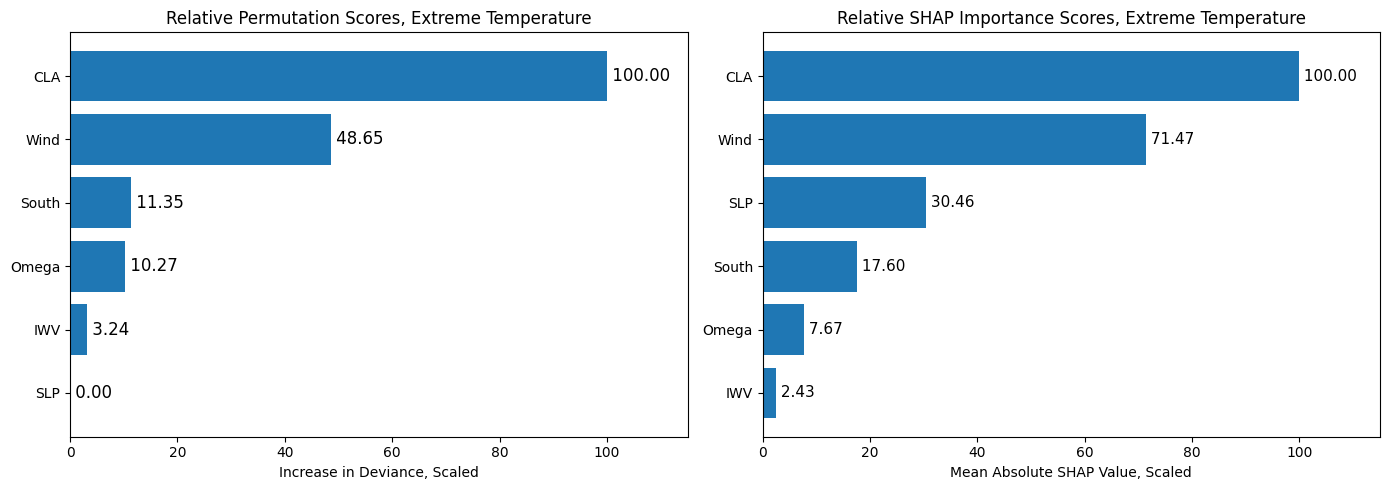

In [28]:
fig, axs = plt.subplots(figsize=(14,5), ncols=2, nrows=1)
tick_labels = [ABBV_DICT[varname] for varname in temp_VI_dat.index]
plot_variable_importance(temp_VI_dat, axs[0], 'Relative Permutation Scores, Extreme Temperature', value_col='avg_perm_diff', 
                         xlabel = 'Increase in Deviance, Scaled', normalize=True, tick_labels=tick_labels)

tick_labels = []
for feat in X_test_temp.columns:
    abbv = ABBV_DICT.get(feat, feat)
    tick_labels.append(f'{abbv}' if units else abbv)
plot_shap_summary_bar(shap_temp, axs[1], tick_labels=tick_labels, 
                      feature_names=X_test_temp.columns, title='Relative SHAP Importance Scores, Extreme Temperature', 
                      xlabel='Mean Absolute SHAP Value, Scaled', normalize=True,
                      label_fmt='{:.2f}')
plt.tight_layout()
plt.savefig('../outputs/plots/extreme_temp_VI.png', dpi=300);